In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [53]:
df = pd.read_csv('train.csv')
print(' Dataset loaded successfully!')

 Dataset loaded successfully!


In [55]:
print(' First 5 rows of the dataset:')
df.head()

 First 5 rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [59]:
# Column names
print(' Column Names:')
print(df.columns.tolist())

 Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [61]:
print(f'Shape of dataset: {df.shape}')
print(f'   {df.shape[0]} rows ')
print(f'   {df.shape[1]} columns (features)')

Shape of dataset: (614, 13)
   614 rows 
   13 columns (features)


In [63]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [65]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [67]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

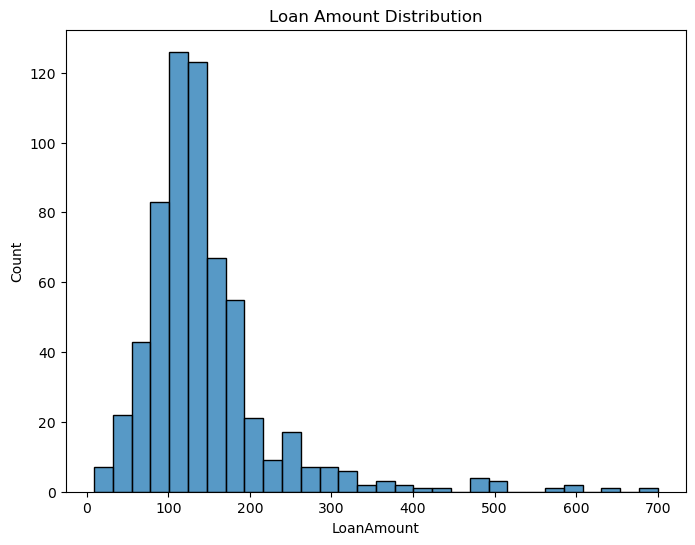

In [69]:
plt.figure(figsize=(8,6))

sns.histplot(df['LoanAmount'], bins=30)

plt.title("Loan Amount Distribution")

plt.show()

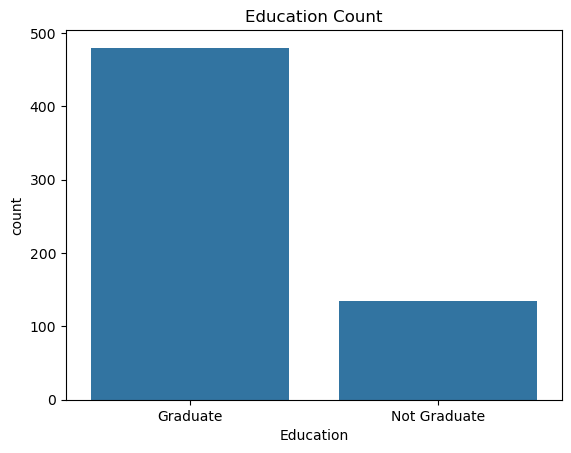

In [71]:
sns.countplot(x='Education', data=df)

plt.title("Education Count")

plt.show()

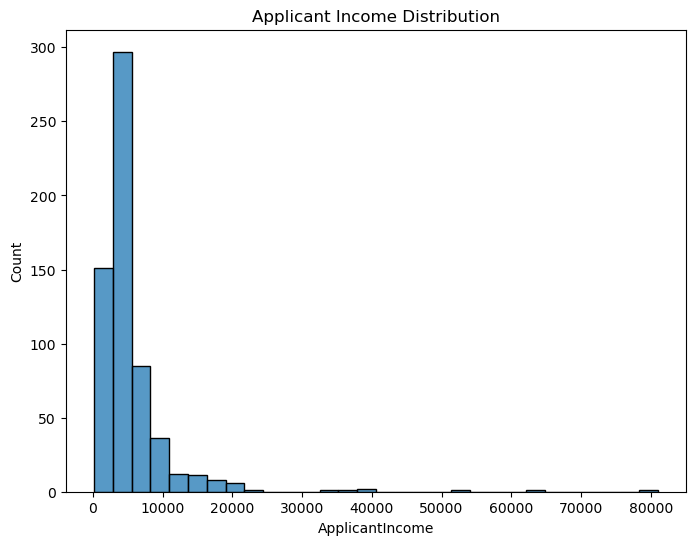

In [73]:
plt.figure(figsize=(8,6))

sns.histplot(df['ApplicantIncome'], bins=30)

plt.title("Applicant Income Distribution")

plt.show()

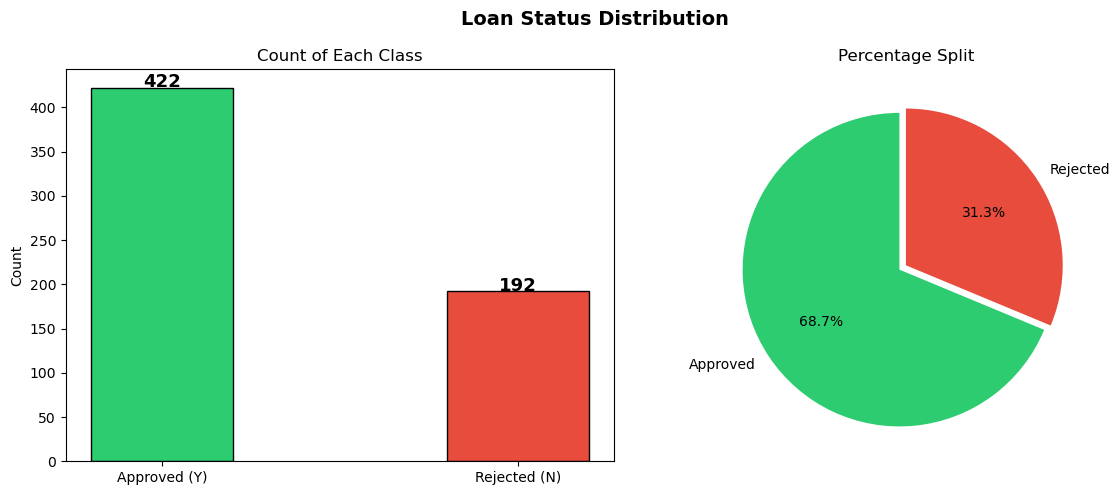

Observation: ~69% loans approved — dataset is slightly imbalanced.


In [97]:
# How many loans were approved vs rejected?
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Loan Status Distribution', fontsize=14, fontweight='bold')

counts = df['Loan_Status'].value_counts()

# Bar chart
bars = axes[0].bar(['Approved (Y)', 'Rejected (N)'],
                   [counts.get(1, counts.get('Y', 0)),
                    counts.get(0, counts.get('N', 0))],
                   color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.4)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].set_title('Count of Each Class')

# Pie chart
axes[1].pie([counts.iloc[0], counts.iloc[1]],
            labels=['Approved', 'Rejected'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0))
axes[1].set_title('Percentage Split')

plt.tight_layout()
plt.show()
print('Observation: ~69% loans approved — dataset is slightly imbalanced.')

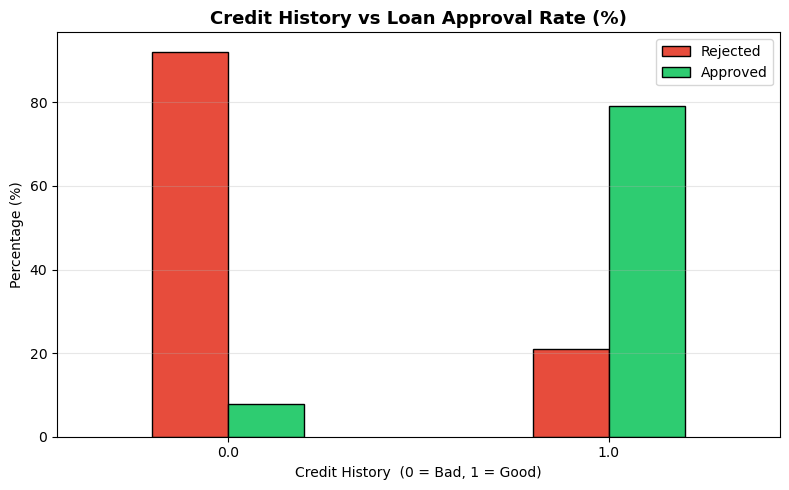

KEY INSIGHT: Good credit history = ~80% approval | Bad credit = ~92% rejection!


In [99]:
# Credit History is the most important feature 
plt.figure(figsize=(8, 5))

ct = df.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).mul(100).unstack()
ct.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black',
        width=0.4, ax=plt.gca(), rot=0)

plt.title('Credit History vs Loan Approval Rate (%)', fontsize=13, fontweight='bold')
plt.xlabel('Credit History  (0 = Bad, 1 = Good)')
plt.ylabel('Percentage (%)')
plt.legend(['Rejected', 'Approved'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print('KEY INSIGHT: Good credit history = ~80% approval | Bad credit = ~92% rejection!')

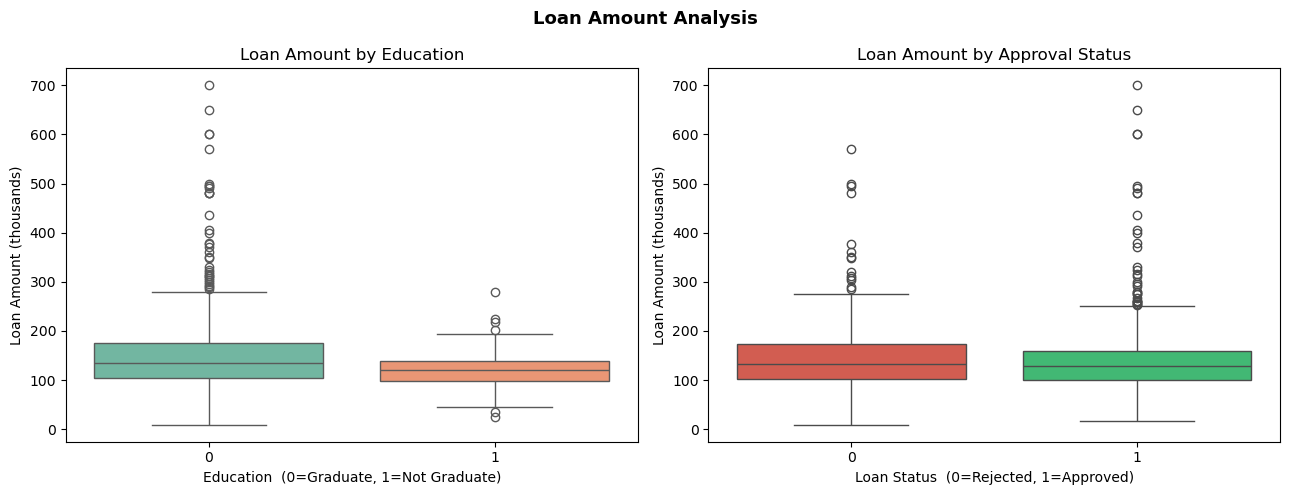

Observation: Graduates tend to request slightly higher loan amounts.


In [123]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Loan Amount Analysis', fontsize=13, fontweight='bold')

# 1. Box plot: LoanAmount by Education (Added hue and legend)
sns.boxplot(data=df, x='Education', y='LoanAmount',
            hue='Education', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Loan Amount by Education')
axes[0].set_xlabel('Education  (0=Graduate, 1=Not Graduate)')
axes[0].set_ylabel('Loan Amount (thousands)')

# 2. Box plot: LoanAmount by Loan Status (Added hue and legend)
sns.boxplot(data=df, x='Loan_Status', y='LoanAmount',
            hue='Loan_Status', palette=['#e74c3c','#2ecc71'], legend=False, ax=axes[1])
axes[1].set_title('Loan Amount by Approval Status')
axes[1].set_xlabel('Loan Status  (0=Rejected, 1=Approved)')
axes[1].set_ylabel('Loan Amount (thousands)')

plt.tight_layout()
plt.show()
print('Observation: Graduates tend to request slightly higher loan amounts.')

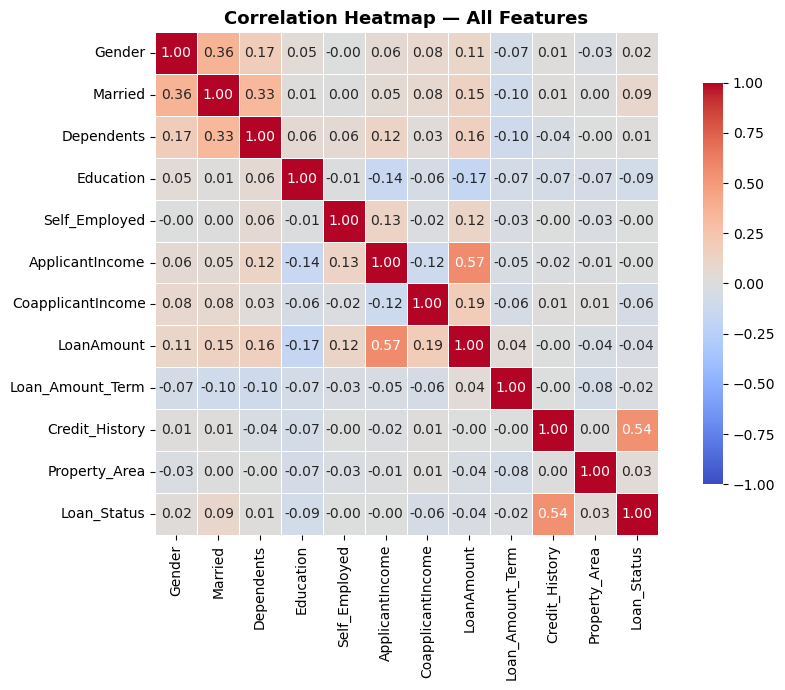

Observation: Credit_History has the strongest correlation with Loan_Status.


In [103]:
plt.figure(figsize=(10, 7))

# Drop Loan_ID for correlation (non-numeric)
num_df = df.drop('Loan_ID', axis=1) if 'Loan_ID' in df.columns else df
corr = num_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap — All Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: Credit_History has the strongest correlation with Loan_Status.')

In [105]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [107]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [109]:
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

y = df['Loan_Status']


In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [112]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [115]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [117]:
y_pred = model.predict(X_test_scaled)

In [119]:
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy)


Model Accuracy:
0.7886178861788617


In [121]:
from sklearn.metrics import classification_report

print('='*50)
print('     Classification Report')
print('='*50)
print(classification_report(y_test, y_pred,
                             target_names=['Rejected (0)', 'Approved (1)']))
print()
print('Precision : Out of all predicted Approved, how many were actually Approved?')
print('Recall    : Out of all actual Approved, how many did model catch?')
print('F1-Score  : Balance between Precision and Recall')

     Classification Report
              precision    recall  f1-score   support

Rejected (0)       0.95      0.42      0.58        43
Approved (1)       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


Precision : Out of all predicted Approved, how many were actually Approved?
Recall    : Out of all actual Approved, how many did model catch?
F1-Score  : Balance between Precision and Recall


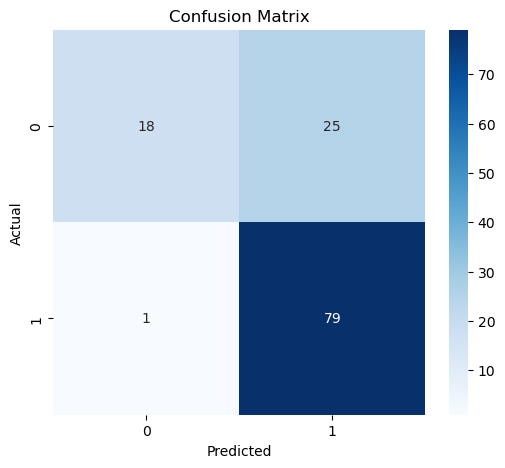

In [95]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()